# Taylor 2.43

Related write-up: [Problem 2.43 in the chapter problem set](problems/README.md)

For quadratic drag,


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Use the basketball values from Problem 2.31 and the initial conditions from 2.43.

In [10]:
g = 9.8
m = 0.600
D = 0.24
gamma = 0.25

c = gamma * D**2

v0 = 15.0
theta = np.deg2rad(45)

x0 = 0.0
y0 = 2.0

vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

print('c =', c)
print('vx0 =', vx0)
print('vy0 =', vy0)

c = 0.0144
vx0 = 10.606601717798213
vy0 = 10.606601717798213


I'll write the state as

\[
[x,\ y,\ v_x,\ v_y].
\]

Then the first two equations are just \(\dot x=v_x\) and \(\dot y=v_y\).

In [11]:
def equations(t, z):
    x, y, vx, vy = z

    v = np.sqrt(vx**2 + vy**2)

    dxdt = vx
    dydt = vy
    dvxdt = -(c/m) * v * vx
    dvydt = -g - (c/m) * v * vy

    return [dxdt, dydt, dvxdt, dvydt]

Stop the solver when the ball reaches the floor, \(y=0\).

In [12]:
def hit_floor(t, z):
    return z[1]

hit_floor.terminal = True
hit_floor.direction = -1

In [13]:
z0 = [x0, y0, vx0, vy0]

sol = solve_ivp(
    equations,
    [0, 10],
    z0,
    events=hit_floor,
    dense_output=True,
    max_step=0.01
)

t_hit = sol.t_events[0][0]
x_hit = sol.y_events[0][0][0]

print('time to hit floor =', t_hit)
print('range with drag =', x_hit)

time to hit floor = 2.169420329540948
range with drag = 17.724036081397013


For comparison, the vacuum trajectory can be written down directly.

In [14]:
t_vac = (vy0 + np.sqrt(vy0**2 + 2*g*y0)) / g
x_vac = vx0 * t_vac

print('vacuum flight time =', t_vac)
print('vacuum range =', x_vac)

vacuum flight time = 2.3391078681591777
vacuum range = 24.80998553253245


Now plot both trajectories.

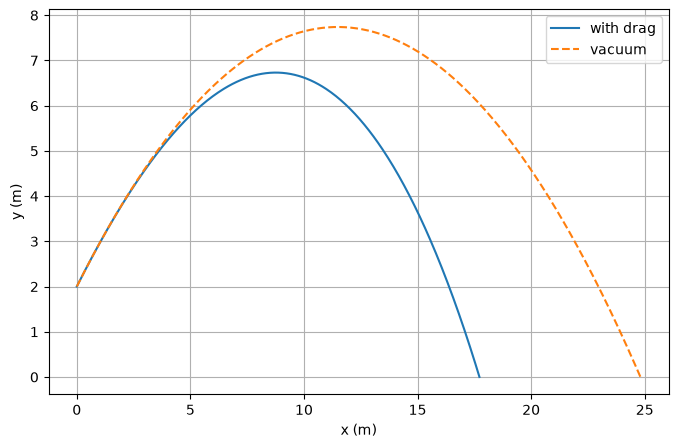

In [15]:
t1 = np.linspace(0, t_hit, 400)
z1 = sol.sol(t1)

x_drag = z1[0]
y_drag = z1[1]

t2 = np.linspace(0, t_vac, 400)
x_vac_plot = vx0 * t2
y_vac_plot = y0 + vy0*t2 - 0.5*g*t2**2

plt.figure(figsize=(8, 5))
plt.plot(x_drag, y_drag, label='with drag')
plt.plot(x_vac_plot, y_vac_plot, '--', label='vacuum')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.legend()
plt.grid()
plt.show()

Finally, compare the two ranges.

In [16]:
print(f'range with drag = {x_hit:.2f} m')
print(f'vacuum range    = {x_vac:.2f} m')
print(f'difference      = {x_vac - x_hit:.2f} m')

range with drag = 17.72 m
vacuum range    = 24.81 m
difference      = 7.09 m


One nice thing about writing the drag term as

\[
-cvv_y
\]

is that I don't have to manually change its sign when the ball starts falling.  
\(v\) is always positive, but \(v_y\) becomes negative on the way down, so the drag force automatically changes direction.